## Using test df

[INFO] device: cuda
[INFO] Loading TEST dataset: /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_test_data.csv
[INFO] Test rows used (after dropna): 4,915
[INFO] Loading scaler: /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/30S/trained_scaler.joblib

[INFO] Top models (by val_rmse):
   model  layer1  layer2  layer3  val_rmse  test_rmse
0    113      90      73      64  7.865381   7.678975
1    165      88      72      72  7.876530   7.677935
2     46      86      72      67  7.892857   7.619819
3     72      83      73      73  7.894812   7.682033
4    122      79      78      64  7.900278   7.663167
5     63      77      74      72  7.900596   7.764092
6    164      90      75      74  7.903996   7.690355
7    162      80      73      65  7.905175   7.646110
8     69      76      69      67  7.907446   7.740903
9    190      87      70      68  7.908843   7.717821

[INFO] Predicting with top models...
[INFO]

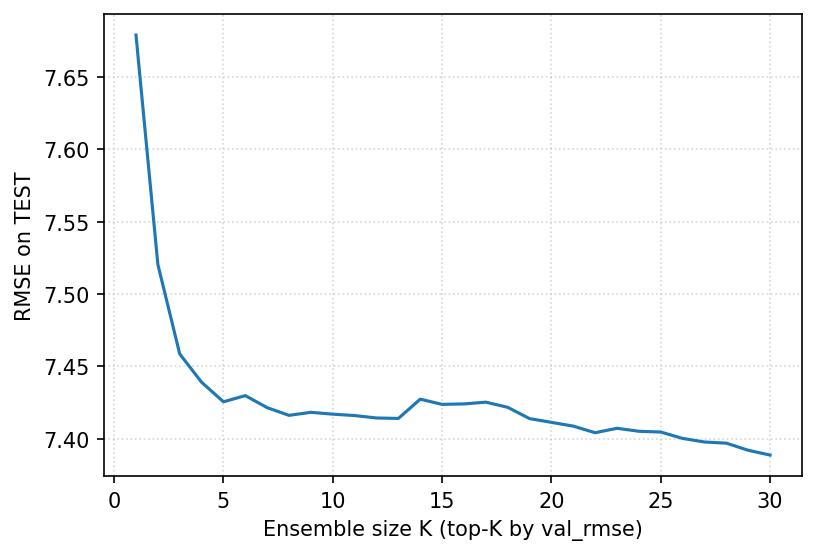


[INFO] First 15 K values:
     K  RMSE_test
0    1   7.678975
1    2   7.520401
2    3   7.458543
3    4   7.438987
4    5   7.425470
5    6   7.429736
6    7   7.421404
7    8   7.416105
8    9   7.418199
9   10   7.416927
10  11   7.415962
11  12   7.414273
12  13   7.413973
13  14   7.427291
14  15   7.423694

[INFO] Models used (in order):
    rank_by_val  layer1  layer2  layer3              file  val_rmse  \
0             1      90      73      64  MLP_90_73_64.pth  7.865381   
1             2      88      72      72  MLP_88_72_72.pth  7.876530   
2             3      86      72      67  MLP_86_72_67.pth  7.892857   
3             4      83      73      73  MLP_83_73_73.pth  7.894812   
4             5      79      78      64  MLP_79_78_64.pth  7.900278   
5             6      77      74      72  MLP_77_74_72.pth  7.900596   
6             7      90      75      74  MLP_90_75_74.pth  7.903996   
7             8      80      73      65  MLP_80_73_65.pth  7.905175   
8             

In [1]:
# ===============================================================
# Ensemble Size Sweep (Top-K models) on FLOATS TEST SET
# Predict with best 1, best 2, best 3, ... best K models (by val_rmse)
# and compute RMSE on the TEST split.
#
# Notes:
# - "Best" models are selected using random_search_model_stats.csv sorted by val_rmse
# - Evaluation here uses FLOATS_pco2_test_data.csv (held-out test split)
# - Architecture files may be:
#     MLP_{l1}_{l2}_{l3}.pth
#   or (recommended to avoid overwriting):
#     MLP_{idx}_{l1}_{l2}_{l3}.pth
# ===============================================================

import os
import re
import numpy as np
import pandas as pd
import torch
import joblib
from torch import nn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG
# -------------------------------
MODEL_DIR = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/30S/"
STATS_CSV = os.path.join(MODEL_DIR, "random_search_model_stats.csv")
SCALER_PATH = os.path.join(MODEL_DIR, "trained_scaler.joblib")

BASE_SPLIT_PATH = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/"
TEST_PATH = os.path.join(BASE_SPLIT_PATH, "FLOATS_pco2_test_data.csv")

TARGET_COL = "FLOATS_pco2_median"  # must exist in TEST csv
TOP_MAX = 30                       # evaluate ensembles of size 1..TOP_MAX

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device:", device)

# Must match training exactly (order matters!)
input_columns = [
    'FLOATS_temperature_median', 'FLOATS_salinity_median', 'MLD', 'sla_median',
    'rrs412', 'rrs443', 'rrs490', 'rrs555', 'rrs670',
    'PAR_mean',
    'u10', 'v10', 'wind_speed',
    'atm_co2',
    'doy_sin', 'doy_cos',
    'x_cart', 'y_cart', 'z_cart',
    'bottom_depth_m'
]

# -------------------------------
# LOAD TEST DATA
# -------------------------------
print(f"[INFO] Loading TEST dataset: {TEST_PATH}")
test_df = pd.read_csv(TEST_PATH, low_memory=False)

missing = [c for c in input_columns + [TARGET_COL] if c not in test_df.columns]
if missing:
    raise ValueError(f"TEST CSV missing columns: {missing}")

test_df = test_df.dropna(subset=input_columns + [TARGET_COL]).copy()
y_true = test_df[TARGET_COL].to_numpy(dtype=float)

print(f"[INFO] Test rows used (after dropna): {len(test_df):,}")

# -------------------------------
# SCALE INPUTS
# -------------------------------
print(f"[INFO] Loading scaler: {SCALER_PATH}")
scaler = joblib.load(SCALER_PATH)

X_scaled = scaler.transform(test_df[input_columns].values)
x_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

# -------------------------------
# READ STATS + PICK TOP-K BY VAL_RMSE
# -------------------------------
if not os.path.exists(STATS_CSV):
    raise FileNotFoundError(f"Stats file not found: {STATS_CSV}")

stats = pd.read_csv(STATS_CSV)
if "val_rmse" not in stats.columns:
    raise ValueError("stats CSV must contain a 'val_rmse' column.")

stats = stats.sort_values("val_rmse", ascending=True).reset_index(drop=True)
top = stats.head(TOP_MAX).copy()

print("\n[INFO] Top models (by val_rmse):")
print(top[["model", "layer1", "layer2", "layer3", "val_rmse", "test_rmse"]].head(10))

# -------------------------------
# MODEL DEFINITION (MATCH TRAINING: GELU)
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, l1, l2, l3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, l3)
        self.fc4 = nn.Linear(l3, 1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        return self.fc4(x)

def find_model_file(l1, l2, l3, model_dir):
    """
    Supports:
      - MLP_{l1}_{l2}_{l3}.pth
      - MLP_{idx}_{l1}_{l2}_{l3}.pth
    Returns a filepath or None.
    """
    files = [f for f in os.listdir(model_dir) if f.endswith(".pth")]

    exact_old = f"MLP_{l1}_{l2}_{l3}.pth"
    if exact_old in files:
        return os.path.join(model_dir, exact_old)

    # idx-prefixed pattern
    pattern = re.compile(rf"^MLP_\d+_{l1}_{l2}_{l3}\.pth$")
    matches = sorted([f for f in files if pattern.match(f)])
    if matches:
        return os.path.join(model_dir, matches[0])

    return None

# -------------------------------
# PREDICT EACH TOP MODEL
# -------------------------------
pred_list = []
used_meta = []

print("\n[INFO] Predicting with top models...")
for i, row in top.iterrows():
    l1, l2, l3 = int(row["layer1"]), int(row["layer2"]), int(row["layer3"])
    pth = find_model_file(l1, l2, l3, MODEL_DIR)

    if pth is None:
        print(f"[WARN] Missing .pth for arch {l1}-{l2}-{l3}. Skipping.")
        continue

    model = MLP(len(input_columns), l1, l2, l3).to(device)
    state = torch.load(pth, map_location=device)
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        pred = model(x_tensor).detach().cpu().numpy().reshape(-1)

    pred_list.append(pred)
    used_meta.append({
        "rank_by_val": len(used_meta) + 1,
        "layer1": l1, "layer2": l2, "layer3": l3,
        "file": os.path.basename(pth),
        "val_rmse": float(row["val_rmse"]),
        "test_rmse_reported": float(row["test_rmse"]) if "test_rmse" in row and pd.notna(row["test_rmse"]) else np.nan
    })

print(f"[INFO] Loaded/predicted {len(pred_list)} models out of requested {TOP_MAX}.")

if len(pred_list) == 0:
    raise RuntimeError("No models were loaded. Check MODEL_DIR and filenames.")

preds = np.stack(pred_list, axis=0)  # (n_models, n_samples)

# -------------------------------
# ENSEMBLE SIZE SWEEP
# -------------------------------
rmse_rows = []
best_k = None
best_rmse = np.inf

for k in range(1, preds.shape[0] + 1):
    ens_pred = preds[:k].mean(axis=0)
    rmse = np.sqrt(mean_squared_error(y_true, ens_pred))
    rmse_rows.append({"K": k, "RMSE_test": rmse})
    if rmse < best_rmse:
        best_rmse = rmse
        best_k = k

rmse_df = pd.DataFrame(rmse_rows)

print("\n[RESULT] Best ensemble size on TEST:")
print(rmse_df.loc[rmse_df["RMSE_test"].idxmin()])

# -------------------------------
# PLOTS + OUTPUT TABLES
# -------------------------------
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(rmse_df["K"], rmse_df["RMSE_test"])
plt.xlabel("Ensemble size K (top-K by val_rmse)")
plt.ylabel("RMSE on TEST")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

used_df = pd.DataFrame(used_meta)

print("\n[INFO] First 15 K values:")
print(rmse_df.head(15))

print("\n[INFO] Models used (in order):")
print(used_df.head(20))

# Optional: save results next to models
out_rmse_csv = os.path.join(MODEL_DIR, "ensemble_size_sweep_TEST_rmse.csv")
out_used_csv = os.path.join(MODEL_DIR, "ensemble_size_sweep_TEST_models_used.csv")

rmse_df.to_csv(out_rmse_csv, index=False)
used_df.to_csv(out_used_csv, index=False)

print(f"\n[SAVED] RMSE-by-K → {out_rmse_csv}")
print(f"[SAVED] Models-used → {out_used_csv}")


## Using independent validation df

[INFO] device: cuda
[INFO] Indep rows used: 1,167
[INFO] Top models (by val_rmse):


,model,layer1,layer2,layer3,val_rmse,test_rmse
0,113,90,73,64,7.865381,7.678975
1,165,88,72,72,7.876530,7.677935
2,46,86,72,67,7.892857,7.619819
3,72,83,73,73,7.894812,7.682033
4,122,79,78,64,7.900278,7.663167
5,63,77,74,72,7.900596,7.764092
6,164,90,75,74,7.903996,7.690355
7,162,80,73,65,7.905175,7.646110
8,69,76,69,67,7.907446,7.740903
9,190,87,70,68,7.908843,7.717821


[INFO] Loaded/predicted 30 models out of requested 30.

[RESULT] Best ensemble size on independent validation:
K       29.00000
RMSE    11.95174
Name: 28, dtype: float64


,K,RMSE
0,1,12.102053
1,2,12.047151
2,3,12.001982
3,4,12.010399
4,5,12.002769
5,6,11.969746
6,7,11.991489
7,8,11.991926
8,9,11.983554
9,10,11.994540


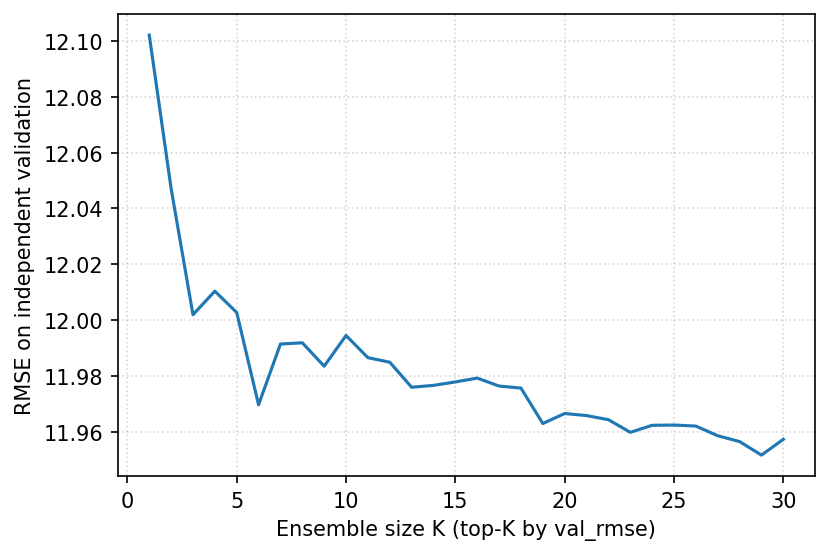

,l1,l2,l3,file,val_rmse
0,90,73,64,MLP_90_73_64.pth,7.865381
1,88,72,72,MLP_88_72_72.pth,7.876530
2,86,72,67,MLP_86_72_67.pth,7.892857
3,83,73,73,MLP_83_73_73.pth,7.894812
4,79,78,64,MLP_79_78_64.pth,7.900278
5,77,74,72,MLP_77_74_72.pth,7.900596
6,90,75,74,MLP_90_75_74.pth,7.903996
7,80,73,65,MLP_80_73_65.pth,7.905175
8,76,69,67,MLP_76_69_67.pth,7.907446
9,87,70,68,MLP_87_70_68.pth,7.908843


In [2]:
import os
import re
import numpy as np
import pandas as pd
import torch
import joblib
from torch import nn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
MODEL_DIR = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/30S/"
STATS_CSV = os.path.join(MODEL_DIR, "random_search_model_stats.csv")
SCALER_PATH = os.path.join(MODEL_DIR, "trained_scaler.joblib")

INDEP_PATH = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/"
    "independent_validation/"
    "pco2_independent_validation_data_TSMLD_SLA_RRS_PAR_WIND_ATM_CO2_feature_engineered_monthly_1deg.csv"
)

TARGET_COL = "FLOATS_pco2_median"     # must exist in INDEP_PATH
TOP_MAX = 30                         # evaluate ensembles 1..TOP_MAX (set 10/15/50 etc)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device:", device)

# Must match training exactly
input_columns = [
    'FLOATS_temperature_median', 'FLOATS_salinity_median', 'MLD', 'sla_median',
    'rrs412', 'rrs443', 'rrs490', 'rrs555', 'rrs670',
    'PAR_mean',
    'u10', 'v10', 'wind_speed',
    'atm_co2',
    'doy_sin', 'doy_cos',
    'x_cart', 'y_cart', 'z_cart',
    'bottom_depth_m'
]

# =========================
# LOAD INDEPENDENT DATA
# =========================
indep_df = pd.read_csv(INDEP_PATH, low_memory=False)

# Ensure required cols exist
missing = [c for c in input_columns + [TARGET_COL] if c not in indep_df.columns]
if missing:
    raise ValueError(f"Independent CSV missing columns: {missing}")

# Drop rows with missing predictors/target (so RMSE is fair)
indep_df = indep_df.dropna(subset=input_columns + [TARGET_COL]).copy()
y_true = indep_df[TARGET_COL].to_numpy(dtype=float)

# Scale X using trained scaler
scaler = joblib.load(SCALER_PATH)
X_scaled = scaler.transform(indep_df[input_columns].values)
x_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

print(f"[INFO] Indep rows used: {len(indep_df):,}")

# =========================
# READ STATS + PICK TOP-K
# =========================
stats = pd.read_csv(STATS_CSV)

# Prefer selecting by val_rmse (best practice)
stats = stats.sort_values("val_rmse", ascending=True).reset_index(drop=True)

top = stats.head(TOP_MAX).copy()
print("[INFO] Top models (by val_rmse):")
display(top[["model", "layer1", "layer2", "layer3", "val_rmse", "test_rmse"]].head(10))

# =========================
# MODEL LOADER
# =========================
class MLP(nn.Module):
    def __init__(self, input_dim, l1, l2, l3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, l3)
        self.fc4 = nn.Linear(l3, 1)
        self.act = nn.GELU()
    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        return self.fc4(x)

def find_model_file(l1, l2, l3):
    """
    Works with:
      - MLP_{l1}_{l2}_{l3}.pth
      - MLP_{idx}_{l1}_{l2}_{l3}.pth (your recommended new naming)
    Returns best match if multiple.
    """
    files = [f for f in os.listdir(MODEL_DIR) if f.endswith(".pth")]
    # exact old pattern
    exact_old = f"MLP_{l1}_{l2}_{l3}.pth"
    if exact_old in files:
        return os.path.join(MODEL_DIR, exact_old)

    # idx-prefixed pattern
    pattern = re.compile(rf"^MLP_\d+_{l1}_{l2}_{l3}\.pth$")
    matches = [f for f in files if pattern.match(f)]
    if matches:
        # choose smallest idx
        matches = sorted(matches)
        return os.path.join(MODEL_DIR, matches[0])

    return None

# =========================
# PREDICT EACH TOP MODEL
# =========================
pred_list = []
used = []

for i, row in top.iterrows():
    l1, l2, l3 = int(row["layer1"]), int(row["layer2"]), int(row["layer3"])
    pth = find_model_file(l1, l2, l3)
    if pth is None:
        print(f"[WARN] missing .pth for arch {l1}-{l2}-{l3}, skipping")
        continue

    model = MLP(len(input_columns), l1, l2, l3).to(device)
    state = torch.load(pth, map_location=device)
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        pred = model(x_tensor).detach().cpu().numpy().reshape(-1)

    pred_list.append(pred)
    used.append((l1, l2, l3, os.path.basename(pth), float(row["val_rmse"])))

print(f"[INFO] Loaded/predicted {len(pred_list)} models out of requested {TOP_MAX}.")
if len(pred_list) == 0:
    raise RuntimeError("No models were loaded. Check MODEL_DIR and filenames.")

preds = np.stack(pred_list, axis=0)  # shape: (n_models, n_samples)

# =========================
# ENSEMBLE SIZE SWEEP
# =========================
rmse_by_k = []
best_k = None
best_rmse = np.inf

for k in range(1, preds.shape[0] + 1):
    ens_pred = preds[:k].mean(axis=0)
    rmse = np.sqrt(mean_squared_error(y_true, ens_pred))
    rmse_by_k.append((k, rmse))
    if rmse < best_rmse:
        best_rmse = rmse
        best_k = k

rmse_df = pd.DataFrame(rmse_by_k, columns=["K", "RMSE"])
print("\n[RESULT] Best ensemble size on independent validation:")
print(rmse_df.loc[rmse_df["RMSE"].idxmin()])

# show a quick table
display(rmse_df.head(15))

# plot RMSE vs K
plt.figure(figsize=(6,4), dpi=150)
plt.plot(rmse_df["K"], rmse_df["RMSE"])
plt.xlabel("Ensemble size K (top-K by val_rmse)")
plt.ylabel("RMSE on independent validation")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

# Optional: list the models used (in order)
used_df = pd.DataFrame(used, columns=["l1","l2","l3","file","val_rmse"])
display(used_df.head(20))
